In [1]:
import os

def _find_project_root(markers=('dhgnn_lib', 'raw_dataset', 'output_tables')):
   
    path = os.path.abspath(os.getcwd())
    while True:
        if all(os.path.isdir(os.path.join(path, m)) for m in markers):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(
                "Could not locate the DHGNN project root (looked for dhgnn_lib/, "
                "raw_dataset/, output_tables/). Start Jupyter from inside the "
                "project folder or its notebooks/ subfolder."
            )
        path = parent

os.chdir(_find_project_root())
print('cwd:', os.getcwd())

cwd: C:\Users\Lenovo\Downloads\DHGNN_26\DHGNN_fixed


FUNCTIONAL LOOKUP TABLE — C. elegans Embryogenesis Project

CANONICAL NOMENCLATURE: Sulston 1983 notation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cells_birth_and_pos.csv and ce_temporal_data.csv both use Sulston notation
natively (e.g. ABplapaaaapp, MSaapa, Cpapa). Using the same convention
throughout the project means zero-translation lookups at every step.

WormBase (Alignment_map.xlsx) uses a slightly different format:
  - Inserts a space after the root:      "AB plapaaaapp"
  - Uses dots for P-lineage cells:       "P1.apa"
  - Appends terminal orientation suffix: "AB alpppapav" (v = ventral)

THREE NORMALIZATION RULES APPLIED:
  Rule 1  Remove all spaces        "AB plapaaaapp" → "ABplapaaaapp"
  Rule 2  Remove dots (AB/MS/P..)  "P1.apa"        → "P1apa"
  Rule 3  Strip suffix v or d      "AB alpppapav"  → "ABalpppapa"

Loading data files...
  Alignment_map_csv.csv  : 1359 rows, 694 unique cells
  Connectome.csv      : 2279 rows, 271 source neurons

  Added 5 missing neurons: 


STEP 9 — Generating Gerstein-Style FFL Motif Grid
  Grid sample: 36 motifs  (33 excitatory, 3 inhibitory)
  Synapse range in grid: 29 – 60


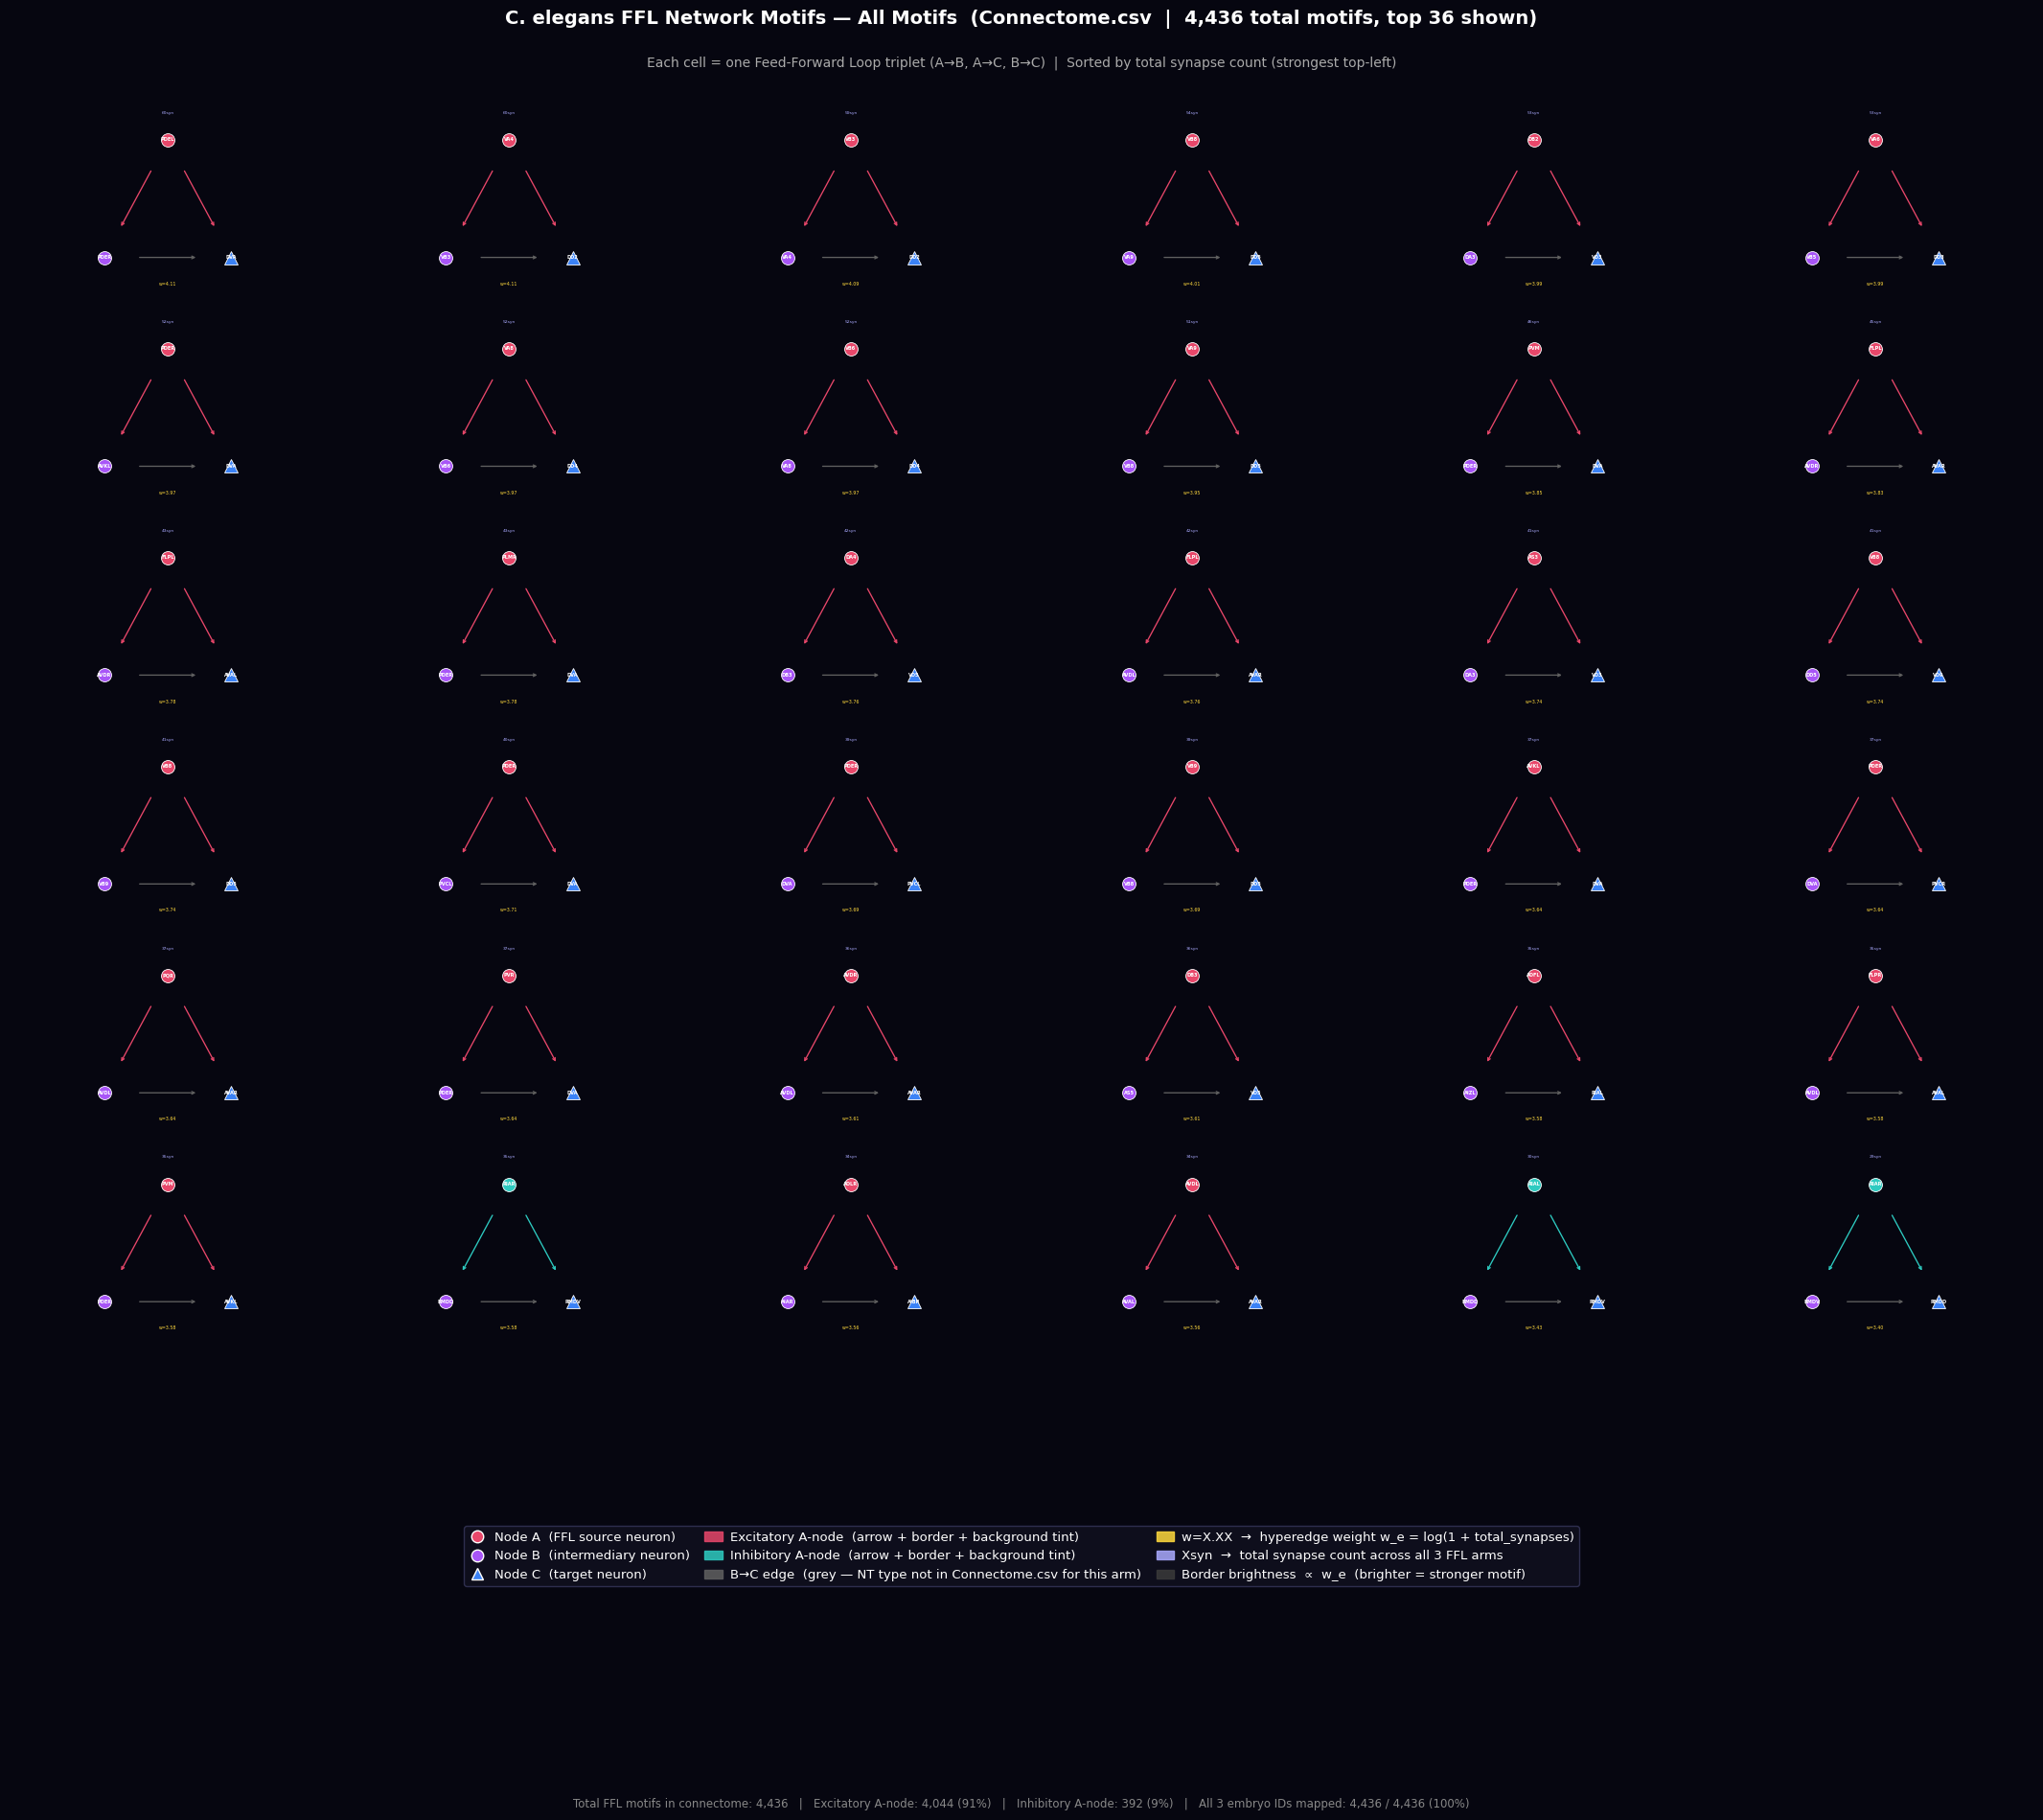


  Figure saved → Figures_and_Visualizations\functional\functional_ffl_motif_grid.png

  HOW TO READ THIS FIGURE:
  ─────────────────────────────────────────────────────────────────
  • Each cell in the grid = one FFL motif from your connectome data
  • Reading left→right, top→bottom: strongest → weakest motifs
  • Pink/red cells   = excitatory A-node (91% of all FFLs)
  • Teal/cyan cells  = inhibitory A-node (9% of all FFLs)
  • Top number (blue)= total synapses across all 3 arms of triangle
  • Bottom number (gold) = w_e = log(1 + synapses) = incidence matrix value
  • Border brightness = relative motif strength (brightest = strongest)
  • In H_functional: each cell in this grid becomes ONE COLUMN of the
    incidence matrix. The 3 embryo Sulston names in that motif are the
    3 ROWS that receive a non-zero entry in that column.


In [2]:
%run dhgnn_lib/build_functional_lookup_table_with_viz.py